# SPY Tear Sheet

A tear sheet is a summary that highlights key information about a portfolio or investment strategy. Its name comes from finance professionals tearing off a sheet from a longer report to give to investors or clients. Tear sheets are usually short, but i would like to dive deeper into the metrics and uncover what they convey about the portfolio.

**PERFORMANCE SUMMARY**

In [52]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

rfr = 0.0225
rfr_daily = rfr/252 # dictated by 3-month t-bill rate

df = yf.download("SPY", start="2020-01-01", end="2026-07-01") # S&P 500 index
data = df['Close'].squeeze()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


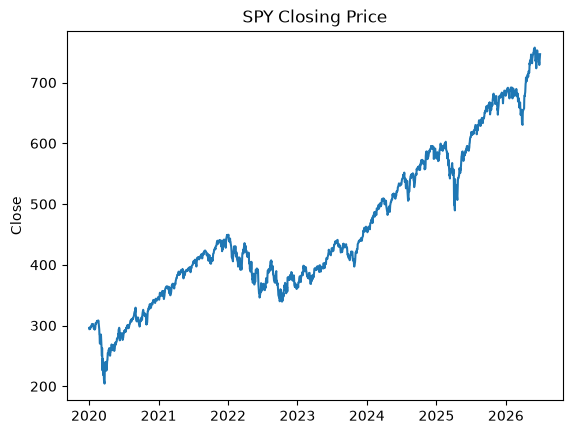

np.float64(296.1253662109375)

In [3]:
plt.plot(data)
plt.ylabel('Close')
plt.title('SPY Closing Price')
plt.show()
data.iloc[0]

Text(0.5, 1.0, 'SPY Daily Returns')

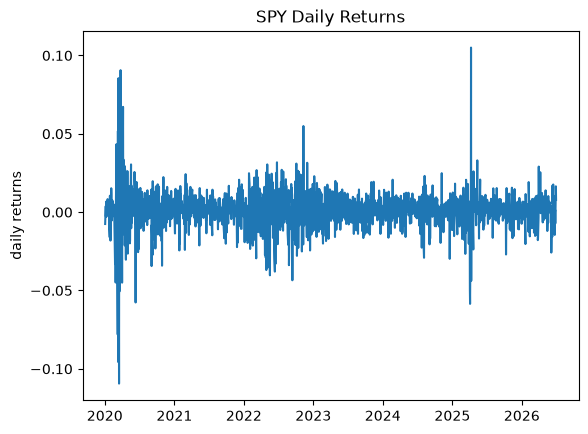

In [4]:
daily_returns = data.pct_change().dropna()
plt.plot(daily_returns)
plt.ylabel('daily returns')
plt.title('SPY Daily Returns')

The daily standard deviation of returns tells us how we can expect an investment to act on a day to day basis. Specifically, it tells us how the investment's daily returns typically deviate from the mean return. It is calculated using the following equation:

$$
\sigma_d = \sqrt{\frac{\Sigma_{i=1}^{n} (R_i - \bar{R})^2}{n - 1}}
$$

Where:
- $\sigma_d$: daily standard deviation
- $R_i$: return of day $i$
- $\bar{R}$: average daily return
- $n$: number of daily returns

In [25]:
daily_std = daily_returns.std().item() # .item() extracts the value from the 1 element dataframe

print(f"Daily Standard Deviation: {daily_std:.2%}")

Daily Standard Deviation: 1.28%


The yearly standard deviation can be extrapolated using the daily standard deviation.
Since variance scale linearly with time, 

$\sigma_y^2 = 252 \times \sigma_d^2$

taking the square root of both sides gives:

$\sigma_y = \sqrt{252} \times \sigma_d$

In [6]:
yearly_std = daily_std*np.sqrt(252)
print(f"Annualized Volatility: {yearly_std*100:.2f}%")

Annualized Volatility: 20.33%


The total cummulative return is the overall percentage return that an investment has achieved over its lifetime.

In [7]:
cum_return = data.iloc[-1] / data.iloc[0]
print(f"Total Cumulative Return: {cum_return.item()*100:.2f}%")

Total Cumulative Return: 252.18%


The compound annual growth rate is the yearly rate of return that would result in the investment growing from its initial value to its final value. This rate can be acquired using the following equation:
$$
\text{CAGR} = \frac{P_{final}}{P_{initial}}^\frac{1}{t} - 1
$$

In [8]:
cagr = (data.iloc[-1] / data.iloc[0])**(1/6) - 1
print(f"Compound Annual Growth Rate: {cagr.item()*100:.2f}%")

Compound Annual Growth Rate: 16.67%


The Sharpe ratio is a measure of an investment's risk adjusted returns. It tells you how much excess return you achieve per unit of risk (Volatility). 
$$
\text{Sharpe ratio} = \frac{E(R) - r_f}{\sigma_y}
$$
Where:
- $E(R)$ : expected return of a portfolio
- $R_f$ : risk free rate.

In [9]:
sharpe = (cagr.item() - rfr) / yearly_std
print(f"Sharpe Ratio: {sharpe:.2f}")

Sharpe Ratio: 0.71


The Sortino Ratio is a similar measure to the Sharpe ratio, but it only uses the negative deviation of returns. This means the ratio is only penalized for having larger negative deviations.

$$
\text{Sortino Ratio}
=
\frac{E(R) - R_f}{\sigma_{negative}}
$$

In [10]:
negative_returns = daily_returns[daily_returns < rfr_daily]
negative_std = negative_returns.std().item()
negative_yearly = negative_std * np.sqrt(252)

sortino = (cagr.item() - rfr) / negative_yearly
print(f"Sortino Ratio: {sortino:.2f}")

Sortino Ratio: 0.88


The Maximum Drawdown is the largest peak-to-trough percentage loss in an investment's value. It is an estimate for the maximum drawdown an investor might experience in the future. We can calculate all drawdowns using the equation:

$$
\text{Drawdown}_t 
= 
\frac{P_t - Peak_t}{Peak_t}
$$

Where:

- $P_t$ : investment price at time $t$
- $Peak_t$ : highest price the investment reached before time $t$

Then we find the most negative value.

$$
\text{Max Drawdown} = \text{min}(\text{Drawdown})
$$




In [24]:
local_max = data.cummax()

drawdown = (data - local_max) / local_max
max_dd = drawdown.min()

print(f"Maximum Drawdown: {max_dd.item():.2%}")

Maximum Drawdown: -33.72%


In [12]:
drawdown = data < local_max

dd_duration = drawdown.groupby((~drawdown).cumsum()).cumsum()

max_dd_days = dd_duration.max()

print(f"Maximum Drawdown Duration: {int(max_dd_days):.0f} days")


Maximum Drawdown Duration: 488 days


The Calmar ratio assesses risk adjusted returns by comparing an investments excess returns to its maximum drawdown, usually over a 3 year period.
$$
\text{Calmar Ratio} = \frac{\text{CAGR} - r_f}{|\text{Maximum Drawdown}|}
$$

In [13]:
calmar = (cagr.item() - rfr) / -max_dd.item()

print(f"Calmar Ratio: {calmar:.2f}")

Calmar Ratio: 0.43


Skewness is a measure of the asymmetry of a distribution around its mean. A negative skew means the distribution has a larger tail to the left of the mean, and a postive skew means the right side has a larger tail. It tells us on which side extreme events are favourable.
$$
\text{Skewness} = \frac{\frac{1}{n}\sum_{i=1}^{n}(R_i - \bar{R})^3}{\sigma_d^3}
$$

The cube maintains the sign of the deviation and amplifies large outliers.

In [14]:
skew = daily_returns.skew()

print(f"Skew: {skew.item():.2f}")

Skew: -0.26


Kurtosis describes the "tailedness" of a distribution by focusing on the probablity of extreme deviations from the mean. It quantifies the risk of experiencing an extreme gain or loss.
$$
\text{Kurtosis} = \frac{\frac{1}{n}\sum_{i=1}^{n}(R_i - \bar{R})^4}{\sigma_d^4}
$$

In [15]:
kurtosis = ((daily_returns - daily_returns.mean())**4).mean() / daily_std**4

print(f"Kurtosis: {kurtosis.item():.2f}")

Kurtosis: 16.11


In [27]:
expected_daily = cagr.item() / 252

print(f"Expected Daily Return: {expected_daily:.3%}")

Expected Daily Return: 0.066%


The Kelly Criterion is a mathematical strategy which determines the fraction of your capital that you should allocate to maximize long term geometric growth. The kelly criterion strategy is meant for repeating and independant bets, but a common approximation for investing is:
$$
f\text{*} = \frac{\mu - r_f}{\sigma^2}
$$
Where:

- $f\text{*}$ : fraction of your bankroll that you should invest
- $\mu$ : expected return of the investment
- $r_f$ : the risk-free rate, and
- $\sigma^2$ : variance of daily returns

In [38]:
kelly_fraction = (daily_returns.mean() - rfr_daily)/ daily_returns.var()

print(f"Kelly Criterion Fraction of Bankroll: {kelly_fraction:.2%}")

Kelly Criterion Fraction of Bankroll: 341.91%


Rolling Volatility estimates the current volatility by taking the average of the volatily seen in the previous chosen amount of days. You can use any window of days to take this average, but common ones for investing are:
- 63 days (one quarter)
- 126 days (six months)
- 252 days (annually)

To calculate the rolling volatility, we use:

$$
\sigma_{t,N} 
=
\sqrt{
\frac{
\sum_{i=t-N+1}^{t}
\left(R_i - \bar{R}_N\right)^2
}
{N-1}
}
$$

Where:
- $\sigma_{t,N}$ : rolling volatility at time $t$
- $N$ : rolling window (days)
- $R_i$ : return on day $i$
- $\bar{R}_N$ : average return over past N days

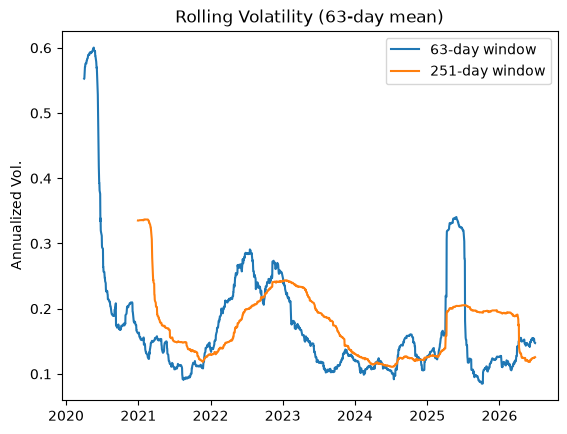

In [37]:
window1 = 63 # quarter
window2 = 252 # annual
rolling_vol1 = daily_returns.rolling(window1).std()*np.sqrt(252)
rolling_vol2 = daily_returns.rolling(window2).std()*np.sqrt(252)
plt.plot(rolling_vol1, label=f"{window1}-day window")
plt.plot(rolling_vol2, label=f"{window2}-day window")
plt.ylabel('Annualized Vol.')
plt.title('Rolling Volatility (63-day mean)')
plt.legend()
plt.show()

The rolling Sharpe ratio calculates the risk adjusted return based on the expected return and the volatility from the previous N days. This method is used to understand how the investment's risk adjusted returns change over time. The equation used is:

$$
\text{Rolling Sharpe}_t 
=
\frac{\bar{R}_{t,N} - r_{f, daily}}{\sigma_{t,N}} \times \sqrt{252}
$$

Where:
- $\bar{R}_{t,N}$ : rolling average returns
- $r_{f,daily}$ : daily risk free rate
- $\sigma_{t,N}$ : rolling standard deviation of returns
- $N$ : rolling window

The $\sqrt{252}$ term is used to annualize the volatility, allowing us to compare the Sharpe values across different time periods.

Text(0.5, 1.0, 'Rolling Sharpe Ratio')

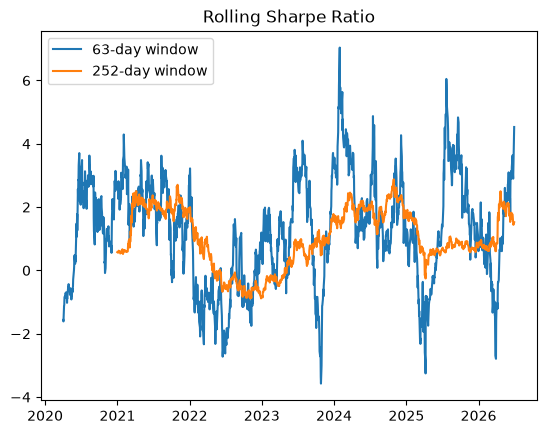

In [47]:
window1 = 63
rolling_mean1 = daily_returns.rolling(window1).mean()
rolling_std1 = daily_returns.rolling(window1).std()
rolling_sharpe1 = ((rolling_mean1 - rfr_daily) / rolling_std1) * np.sqrt(252)

window2 = 252
rolling_mean2 = daily_returns.rolling(window2).mean()
rolling_std2 = daily_returns.rolling(window2).std()
rolling_sharpe2 = ((rolling_mean2 - rfr_daily) / rolling_std2) * np.sqrt(252)


plt.plot(rolling_sharpe1, label=f"{window1}-day window")
plt.plot(rolling_sharpe2, label=f"{window2}-day window")
plt.legend()
plt.title('Rolling Sharpe Ratio')

The rolling Sortino ratio is similar to the rolling Sharpe ratio, with the only difference being the Sortino ratio uses downside deviations

$$
\text{Rolling Sortino}_t 
=
\frac{\bar{R}_{t,N} - r_{f, daily}}{\sigma_{d,t,N}} \times \sqrt{252}
$$

Where:
- $\bar{R}_{t,N}$ : rolling average returns
- $r_{f,daily}$ : daily risk free rate
- $\sigma_{d,t,N}$ : rolling downside deviation
- $N$ : rolling window

Text(0.5, 1.0, 'Rolling Sortino Ratio')

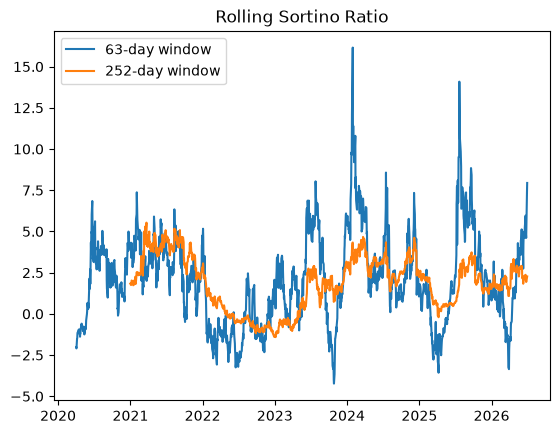

In [50]:
window1 = 63
window2 = 252

downside_returns = np.minimum(daily_returns - rfr_daily, 0)

rolling_downside_std1 = np.sqrt((downside_returns**2).rolling(window).mean())
rolling_downside_std2 = np.sqrt((downside_returns**2).rolling(window).mean())
rolling_sortino1 = ((daily_returns.rolling(window1).mean() - rfr/252) / rolling_downside_std) * np.sqrt(252)
rolling_sortino2 = ((daily_returns.rolling(window2).mean() - rfr/252) / rolling_downside_std) * np.sqrt(252)

plt.plot(rolling_sortino1, label=f"{window1}-day window")
plt.plot(rolling_sortino2, label=f"{window2}-day window")
plt.legend()
plt.title("Rolling Sortino Ratio")

The CAPM regression is a tool used to determine the expected return of an investment based on its sensitivity to market returns. It is modeled by

$$
E(R_i) 
= 
r_f + \beta_i(E(R_m)-r_f)
$$
Where:
- $E(R_i)$ : expected return of the asset
- $r_f$ : risk free rate
- $\beta_i$ : beta of the asset
- $E(R_m)$ : expected market return
- $E(R_m) - r_f$ : market risk premium

The asset's Beta $\beta$ is deduced using the equation:
$$
\beta_i = \frac{\text{Cov}(R_i,R_m)}{\text{Var}(R_m)}
$$

and measures how sensitive an asset is to market movements.

The term $E(R_m) - r_f$ is the market risk premium term, meaning the return that investors expect by investing in the market and taking on risk.



[*********************100%***********************]  1 of 1 completed


The value of Beta for this regression is 1.006658


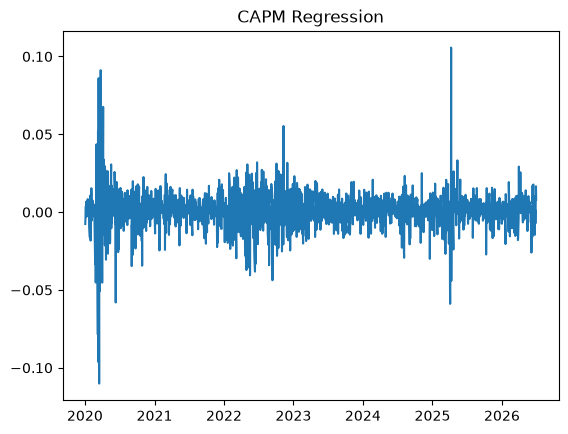

In [58]:
df = yf.download("^GSPC", start="2020-01-01", end="2026-07-01").squeeze() # Actual S&P 500 prices
sp500 = df['Close'].squeeze()
sp500_returns = sp500.pct_change().dropna()

B = daily_returns.cov(sp500_returns) / daily_returns.var()

capm = rfr_daily + B * (daily_returns - rfr_daily)

print(f"The value of Beta for this regression is {B:2f}")

plt.plot(capm)
plt.title('CAPM Regression')
plt.show()

Because SPY has a beta $\beta$ of near 1 relative to the S&P 500, CAPM implies that SPY's expected return closely matches the expected market return."


**Conclusion**



-tear sheet is a great way to condense a lot of information into a meaningful way
-it includes metrics that display the asset's performace, risk, return distribution, etc.